> ⚠️ **Historical Reference Note:** This notebook uses historical V2 models (e.g., est_model.pkl, xgb_model.pkl, lgb_model.pkl). The final production deployment uses the V3 models located in models/v3/.

# 📊 Phase 6 — Evaluation & Final Reporting

**Bank Cash Optimization Project**  
Comprehensive model evaluation, per-branch analysis, aur final business reporting.

---

## Step 1: Libraries & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

# ─── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#c0c0d0',
    'xtick.color':      '#c0c0d0',
    'ytick.color':      '#c0c0d0',
    'text.color':       '#e0e0f0',
    'grid.color':       '#2a2a3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
})

os.makedirs('eda_plots', exist_ok=True)
os.makedirs('models',    exist_ok=True)

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [2]:
# ─── Load Model ──────────────────────────────────────────────────────────────
model = joblib.load('models/best_model.pkl')
print(f'✅ Model loaded: {type(model).__name__}')

# ─── Load Train/Test Data ────────────────────────────────────────────────────
X_train = pd.read_csv('model_data/X_train.csv')
X_test  = pd.read_csv('model_data/X_test.csv')
y_train = pd.read_csv('model_data/y_train.csv').squeeze()
y_test  = pd.read_csv('model_data/y_test.csv').squeeze()

print(f'✅ X_test shape  : {X_test.shape}')
print(f'   y_test shape  : {y_test.shape}')

# ─── Load Daily Full (branch metadata) ──────────────────────────────────────
daily_full = pd.read_csv('model_data/daily_full.csv', parse_dates=['start_date'])
print(f'✅ daily_full shape: {daily_full.shape}')

# ─── Feature Columns ─────────────────────────────────────────────────────────
with open('model_data/feature_cols.json', 'r') as f:
    feature_cols = json.load(f)
print(f'✅ Features: {len(feature_cols)}')

✅ Model loaded: XGBRegressor
✅ X_test shape  : (1731, 22)
   y_test shape  : (1731,)
✅ daily_full shape: (8582, 27)
✅ Features: 22


---
## Step 2: Predictions Generate Karna

In [3]:
# ─── Predictions ─────────────────────────────────────────────────────────────
y_pred_train = model.predict(X_train[feature_cols])
y_pred_test  = model.predict(X_test[feature_cols])

# ─── Residuals ────────────────────────────────────────────────────────────────
residuals = y_test.values - y_pred_test   # actual - predicted
errors_pct = residuals / np.where(y_test.values == 0, np.nan, y_test.values) * 100

print(f'✅ Predictions done.')
print(f'   Train predictions shape: {y_pred_train.shape}')
print(f'   Test  predictions shape: {y_pred_test.shape}')
print(f'   Residuals range: {residuals.min()/1e6:.2f}M  to  {residuals.max()/1e6:.2f}M PKR')

✅ Predictions done.
   Train predictions shape: (6851,)
   Test  predictions shape: (1731,)
   Residuals range: -107.38M  to  127.96M PKR


---
## Step 3: Comprehensive Metrics (Overall)

In [4]:
def compute_metrics(y_true, y_pred, label=''):
    """Compute MAE, RMSE, MAPE, R2, MedAE."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {
        'Set'   : label,
        'MAE_M' : round(mae   / 1e6, 3),
        'RMSE_M': round(rmse  / 1e6, 3),
        'MedAE_M': round(medae/ 1e6, 3),
        'MAPE_%': round(mape, 2),
        'R2'    : round(r2, 4),
    }

train_metrics = compute_metrics(y_train.values, y_pred_train, 'Train (XGBoost)')
test_metrics  = compute_metrics(y_test.values,  y_pred_test,  'Test  (XGBoost)')

metrics_df = pd.DataFrame([train_metrics, test_metrics])
print('\n📊 Overall Metrics (PKR in Millions):')
print(metrics_df.to_string(index=False))

# Overfitting check
gap = train_metrics['R2'] - test_metrics['R2']
print(f'\n🔍 Train R² - Test R² = {gap:.4f}  →  ', end='')
print('⚠️ Overfitting present' if gap > 0.15 else '✅ No significant overfitting')


📊 Overall Metrics (PKR in Millions):
            Set  MAE_M  RMSE_M  MedAE_M  MAPE_%     R2
Train (XGBoost)  6.292   8.512    4.820  124.46 0.9449
Test  (XGBoost) 14.249  20.288   10.361   62.13 0.5607

🔍 Train R² - Test R² = 0.3842  →  ⚠️ Overfitting present


---
## Step 4: Per-Branch Evaluation

In [5]:
# ─── Attach branch code to test data ─────────────────────────────────────────
test_eval = X_test[['tran_br_code']].copy()
test_eval['y_actual']    = y_test.values
test_eval['y_predicted'] = y_pred_test
test_eval['residual']    = residuals
test_eval['abs_error']   = np.abs(residuals)

# Per-branch metrics
branch_metrics = []
for branch, grp in test_eval.groupby('tran_br_code'):
    ya = grp['y_actual'].values
    yp = grp['y_predicted'].values
    mask = ya != 0
    mae  = mean_absolute_error(ya, yp)
    rmse = np.sqrt(mean_squared_error(ya, yp))
    r2   = r2_score(ya, yp) if len(ya) > 1 else np.nan
    mape = np.mean(np.abs((ya[mask] - yp[mask]) / ya[mask])) * 100 if mask.sum() > 0 else np.nan
    avg_actual = ya.mean() / 1e6
    branch_metrics.append({
        'Branch': int(branch),
        'N_Days': len(grp),
        'Avg_Actual_M': round(avg_actual, 2),
        'MAE_M':  round(mae  / 1e6, 2),
        'RMSE_M': round(rmse / 1e6, 2),
        'MAPE_%': round(mape, 1),
        'R2':     round(r2,   4),
    })

branch_df = pd.DataFrame(branch_metrics).sort_values('MAE_M', ascending=True)
print('\n📊 Per-Branch Evaluation (sorted by MAE):')
print(branch_df.to_string(index=False))

best_branch  = branch_df.iloc[0]
worst_branch = branch_df.iloc[-1]
print(f'\n✅ Best  predicted branch: {int(best_branch["Branch"])}  (MAE = {best_branch["MAE_M"]}M PKR)')
print(f'⚠️ Worst predicted branch: {int(worst_branch["Branch"])} (MAE = {worst_branch["MAE_M"]}M PKR)')


📊 Per-Branch Evaluation (sorted by MAE):
 Branch  N_Days  Avg_Actual_M  MAE_M  RMSE_M  MAPE_%      R2
    511     108         30.83   7.26    9.30    25.9 -0.0561
    394     105         29.91   9.35   12.39    41.0  0.1052
    202     105         44.06  10.31   12.80    26.2  0.3322
    659     114         33.24  10.55   14.02    50.0  0.1916
    593     114         28.30  11.04   14.94    96.6  0.0924
   1297     128         56.42  11.20   15.45    21.2  0.1234
    287     127         25.11  11.38   14.29   281.6  0.2515
    372     105         34.61  11.84   15.28    38.0 -0.0951
   1739     105         27.32  12.49   16.93    52.7 -0.0754
    234     106         49.38  13.41   18.45    42.2 -0.0330
   1092     127         40.79  13.85   18.68    43.5  0.2267
   1376     126         47.05  14.80   18.94    66.5  0.4827
   1046     127         60.20  19.65   25.45    46.9  0.1924
   1200     107         60.31  22.00   27.81    41.2  0.1420
    104     127        107.32  31.70   41.6

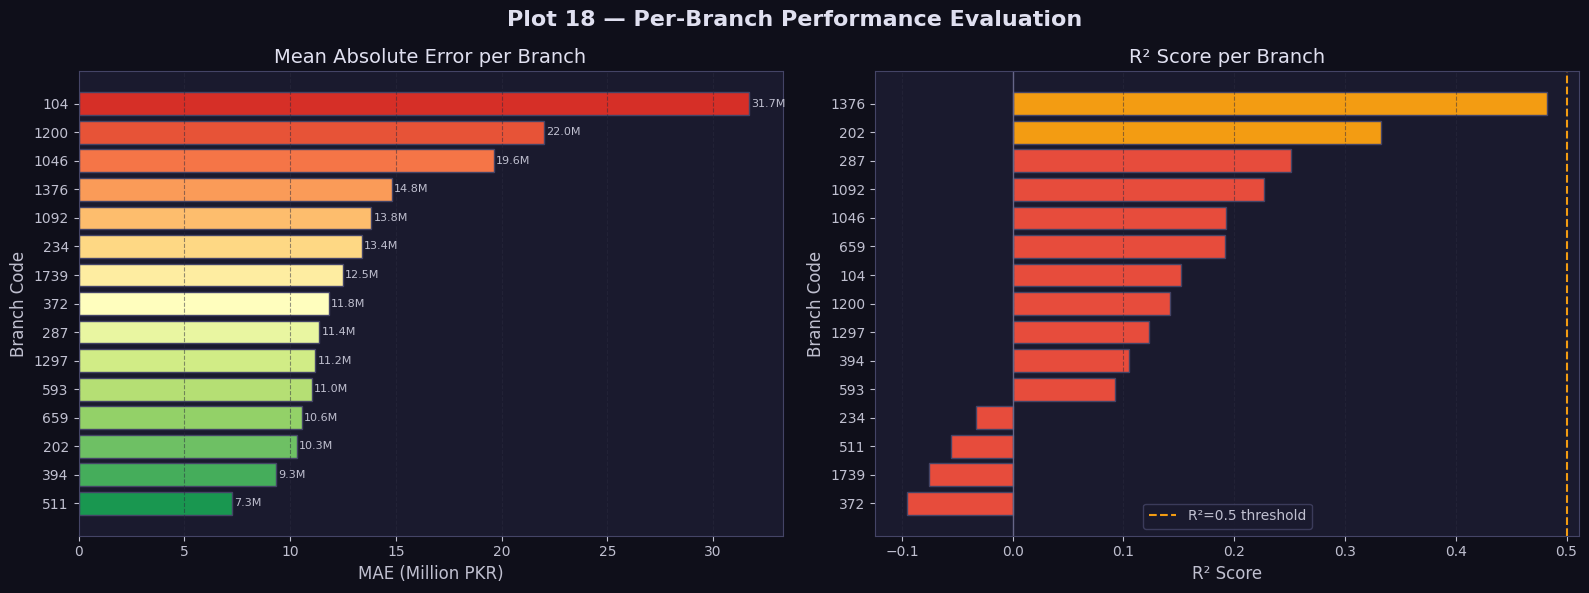

✅ Plot 18 saved: eda_plots/18_branch_wise_evaluation.png


In [6]:
# ─── Plot 18: Per-Branch MAE ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Plot 18 — Per-Branch Performance Evaluation', fontsize=16, fontweight='bold', color='#e0e0f0')

palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(branch_df)))

# Left: MAE per branch
ax1 = axes[0]
bars = ax1.barh(branch_df['Branch'].astype(str), branch_df['MAE_M'], color=palette, edgecolor='#444466')
ax1.set_xlabel('MAE (Million PKR)', color='#c0c0d0')
ax1.set_ylabel('Branch Code', color='#c0c0d0')
ax1.set_title('Mean Absolute Error per Branch', color='#e0e0f0')
ax1.grid(True, axis='x')
for bar, val in zip(bars, branch_df['MAE_M']):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}M', va='center', fontsize=8, color='#c0c0d0')

# Right: R² per branch
ax2 = axes[1]
r2_sorted = branch_df.sort_values('R2', ascending=True)
r2_colors = ['#e74c3c' if v < 0.3 else '#f39c12' if v < 0.6 else '#2ecc71' for v in r2_sorted['R2']]
bars2 = ax2.barh(r2_sorted['Branch'].astype(str), r2_sorted['R2'], color=r2_colors, edgecolor='#444466')
ax2.axvline(x=0, color='#666688', linewidth=1)
ax2.axvline(x=0.5, color='#f39c12', linewidth=1.5, linestyle='--', label='R²=0.5 threshold')
ax2.set_xlabel('R² Score', color='#c0c0d0')
ax2.set_ylabel('Branch Code', color='#c0c0d0')
ax2.set_title('R² Score per Branch', color='#e0e0f0')
ax2.legend(facecolor='#1a1a2e', edgecolor='#444466', labelcolor='#c0c0d0')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.savefig('eda_plots/18_branch_wise_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('✅ Plot 18 saved: eda_plots/18_branch_wise_evaluation.png')

---
## Step 5: Error Distribution Analysis

In [7]:
# ─── Error Stats ─────────────────────────────────────────────────────────────
res_M = residuals / 1e6
over_pred  = (residuals < 0).sum()   # predicted > actual
under_pred = (residuals > 0).sum()   # predicted < actual
exact_pct  = (np.abs(residuals) < 5e6).sum() / len(residuals) * 100  # within 5M

print('📊 Error Analysis:')
print(f'   Total test samples  : {len(residuals)}')
print(f'   Over-predicted      : {over_pred}  ({over_pred/len(residuals)*100:.1f}%) — model predicted TOO HIGH')
print(f'   Under-predicted     : {under_pred} ({under_pred/len(residuals)*100:.1f}%) — model predicted TOO LOW')
print(f'   Within ±5M PKR      : {exact_pct:.1f}% of predictions')
print(f'   Mean Residual       : {res_M.mean():.2f}M PKR  (bias)')
print(f'   Std of Residuals    : {res_M.std():.2f}M PKR')

📊 Error Analysis:
   Total test samples  : 1731
   Over-predicted      : 939  (54.2%) — model predicted TOO HIGH
   Under-predicted     : 792 (45.8%) — model predicted TOO LOW
   Within ±5M PKR      : 27.3% of predictions
   Mean Residual       : 0.05M PKR  (bias)
   Std of Residuals    : 20.29M PKR


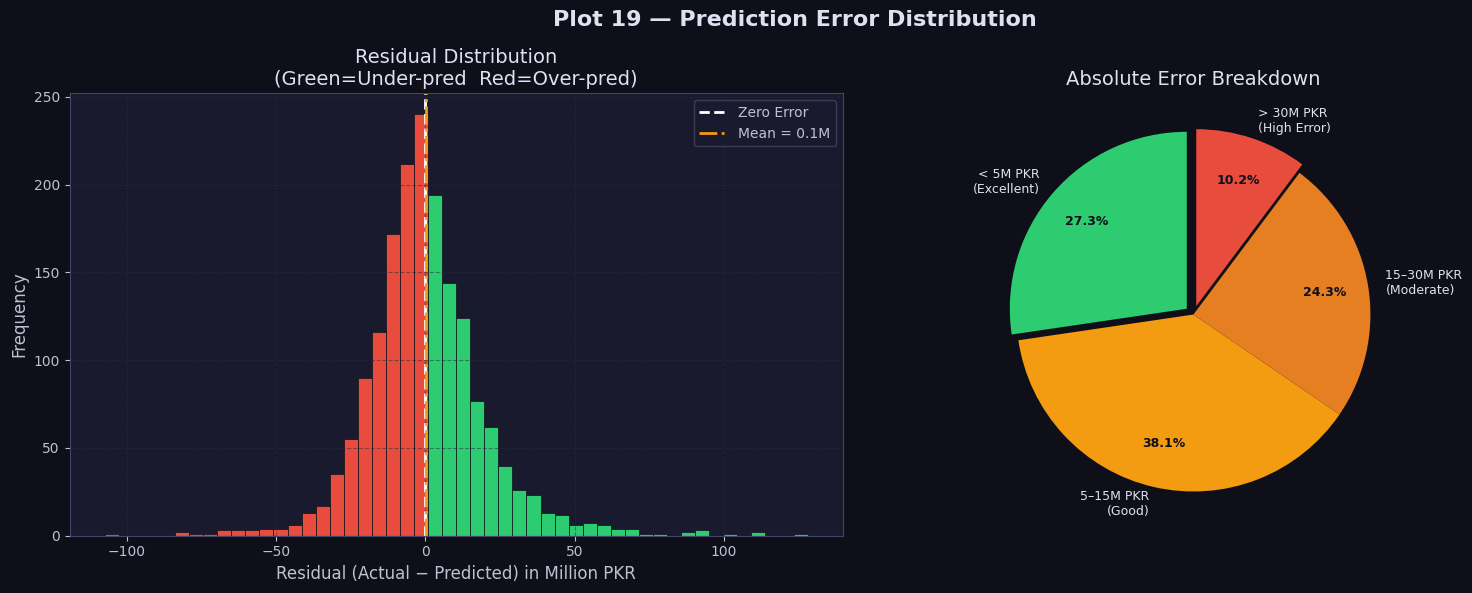

✅ Plot 19 saved: eda_plots/19_error_distribution.png


In [8]:
# ─── Plot 19: Error Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Plot 19 — Prediction Error Distribution', fontsize=16, fontweight='bold', color='#e0e0f0')

# Left: Residual histogram
ax1 = axes[0]
n, bins, patches = ax1.hist(res_M, bins=50, edgecolor='#0f0f1a', linewidth=0.5)
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor('#e74c3c' if left < 0 else '#2ecc71')
ax1.axvline(0, color='white', linewidth=2, linestyle='--', label='Zero Error')
ax1.axvline(res_M.mean(), color='#f39c12', linewidth=2, linestyle='-.',
            label=f'Mean = {res_M.mean():.1f}M')
ax1.set_xlabel('Residual (Actual − Predicted) in Million PKR', color='#c0c0d0')
ax1.set_ylabel('Frequency', color='#c0c0d0')
ax1.set_title('Residual Distribution\n(Green=Under-pred  Red=Over-pred)', color='#e0e0f0')
ax1.legend(facecolor='#1a1a2e', edgecolor='#444466', labelcolor='#c0c0d0')
ax1.grid(True)

# Right: Error Pie
ax2 = axes[1]
within_5  = (np.abs(residuals) < 5e6).sum()
within_15 = ((np.abs(residuals) >= 5e6) & (np.abs(residuals) < 15e6)).sum()
within_30 = ((np.abs(residuals) >= 15e6) & (np.abs(residuals) < 30e6)).sum()
above_30  = (np.abs(residuals) >= 30e6).sum()

sizes  = [within_5, within_15, within_30, above_30]
labels = ['< 5M PKR\n(Excellent)', '5–15M PKR\n(Good)', '15–30M PKR\n(Moderate)', '> 30M PKR\n(High Error)']
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
explode = [0.05, 0, 0, 0.05]

wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=90,
    textprops={'color': '#e0e0f0', 'fontsize': 9},
    pctdistance=0.75
)
for at in autotexts:
    at.set_color('#0f0f1a')
    at.set_fontweight('bold')
ax2.set_title('Absolute Error Breakdown', color='#e0e0f0')

plt.tight_layout()
plt.savefig('eda_plots/19_error_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('✅ Plot 19 saved: eda_plots/19_error_distribution.png')

---
## Step 6: Residual Analysis (Heteroscedasticity Check)

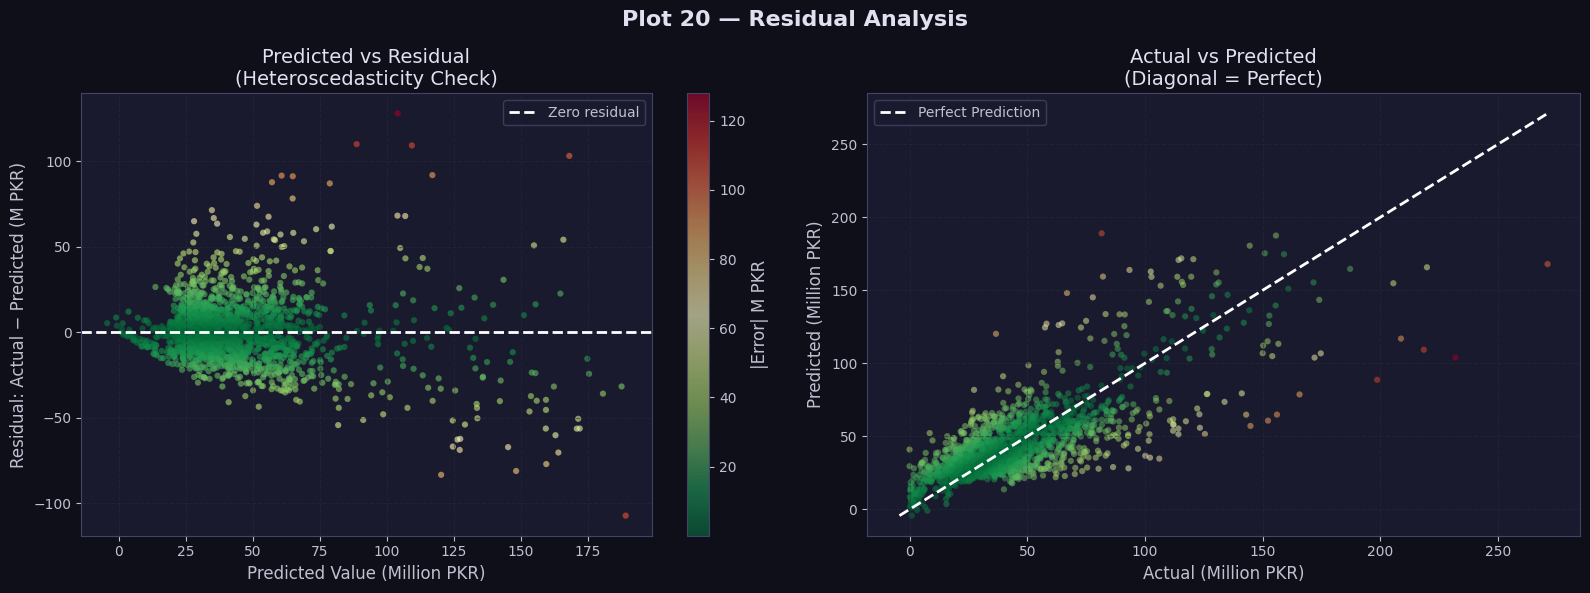

✅ Plot 20 saved: eda_plots/20_residuals_plot.png


In [9]:
# ─── Plot 20: Residuals Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Plot 20 — Residual Analysis', fontsize=16, fontweight='bold', color='#e0e0f0')

pred_M   = y_pred_test / 1e6
actual_M = y_test.values / 1e6

# Left: Predicted vs Residual
ax1 = axes[0]
sc = ax1.scatter(pred_M, res_M, c=np.abs(res_M), cmap='RdYlGn_r',
                 alpha=0.6, edgecolors='none', s=20)
ax1.axhline(0, color='white', linewidth=2, linestyle='--', label='Zero residual')
plt.colorbar(sc, ax=ax1, label='|Error| M PKR')
ax1.set_xlabel('Predicted Value (Million PKR)', color='#c0c0d0')
ax1.set_ylabel('Residual: Actual − Predicted (M PKR)', color='#c0c0d0')
ax1.set_title('Predicted vs Residual\n(Heteroscedasticity Check)', color='#e0e0f0')
ax1.legend(facecolor='#1a1a2e', edgecolor='#444466', labelcolor='#c0c0d0')
ax1.grid(True)

# Right: Actual vs Predicted (Diagonal Line)
ax2 = axes[1]
ax2.scatter(actual_M, pred_M, c=np.abs(res_M), cmap='RdYlGn_r',
            alpha=0.5, edgecolors='none', s=20)
lims = [min(actual_M.min(), pred_M.min()), max(actual_M.max(), pred_M.max())]
ax2.plot(lims, lims, 'w--', linewidth=2, label='Perfect Prediction')
ax2.set_xlabel('Actual (Million PKR)', color='#c0c0d0')
ax2.set_ylabel('Predicted (Million PKR)', color='#c0c0d0')
ax2.set_title('Actual vs Predicted\n(Diagonal = Perfect)', color='#e0e0f0')
ax2.legend(facecolor='#1a1a2e', edgecolor='#444466', labelcolor='#c0c0d0')
ax2.grid(True)

plt.tight_layout()
plt.savefig('eda_plots/20_residuals_plot.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('✅ Plot 20 saved: eda_plots/20_residuals_plot.png')

---
## Step 7: Top Branches — Detailed Timeline

In [10]:
# ─── Identify Top 3 Branches by Volume ───────────────────────────────────────
top3_branches = branch_df.sort_values('Avg_Actual_M', ascending=False).head(3)['Branch'].tolist()
print(f'Top 3 high-volume branches: {top3_branches}')

# Rebuild full test eval with dates using daily_full
daily_test = daily_full.copy()

# We need to align X_test rows with daily_full dates
# X_test has same index order as daily_full test split — use tran_br_code + sequential matching
test_eval2 = X_test[['tran_br_code']].copy().reset_index(drop=True)
test_eval2['y_actual']    = y_test.values
test_eval2['y_predicted'] = y_pred_test

# Try to get dates from daily_full by matching rows
# daily_full should have a 'Date' column
if 'start_date' in daily_full.columns:
    # Get test portion: last 1731 rows matching branch codes
    daily_test_rows = daily_full[daily_full['tran_br_code'].isin(top3_branches)].copy()
    daily_test_rows = daily_test_rows.sort_values(['tran_br_code', 'start_date'])
    print(f'Daily full (top branches) shape: {daily_test_rows.shape}')
else:
    print('No Date column found in daily_full — using row index for timeline')

print('✅ Top branches identified')

Top 3 high-volume branches: [104, 1200, 1046]
Daily full (top branches) shape: (1796, 27)
✅ Top branches identified


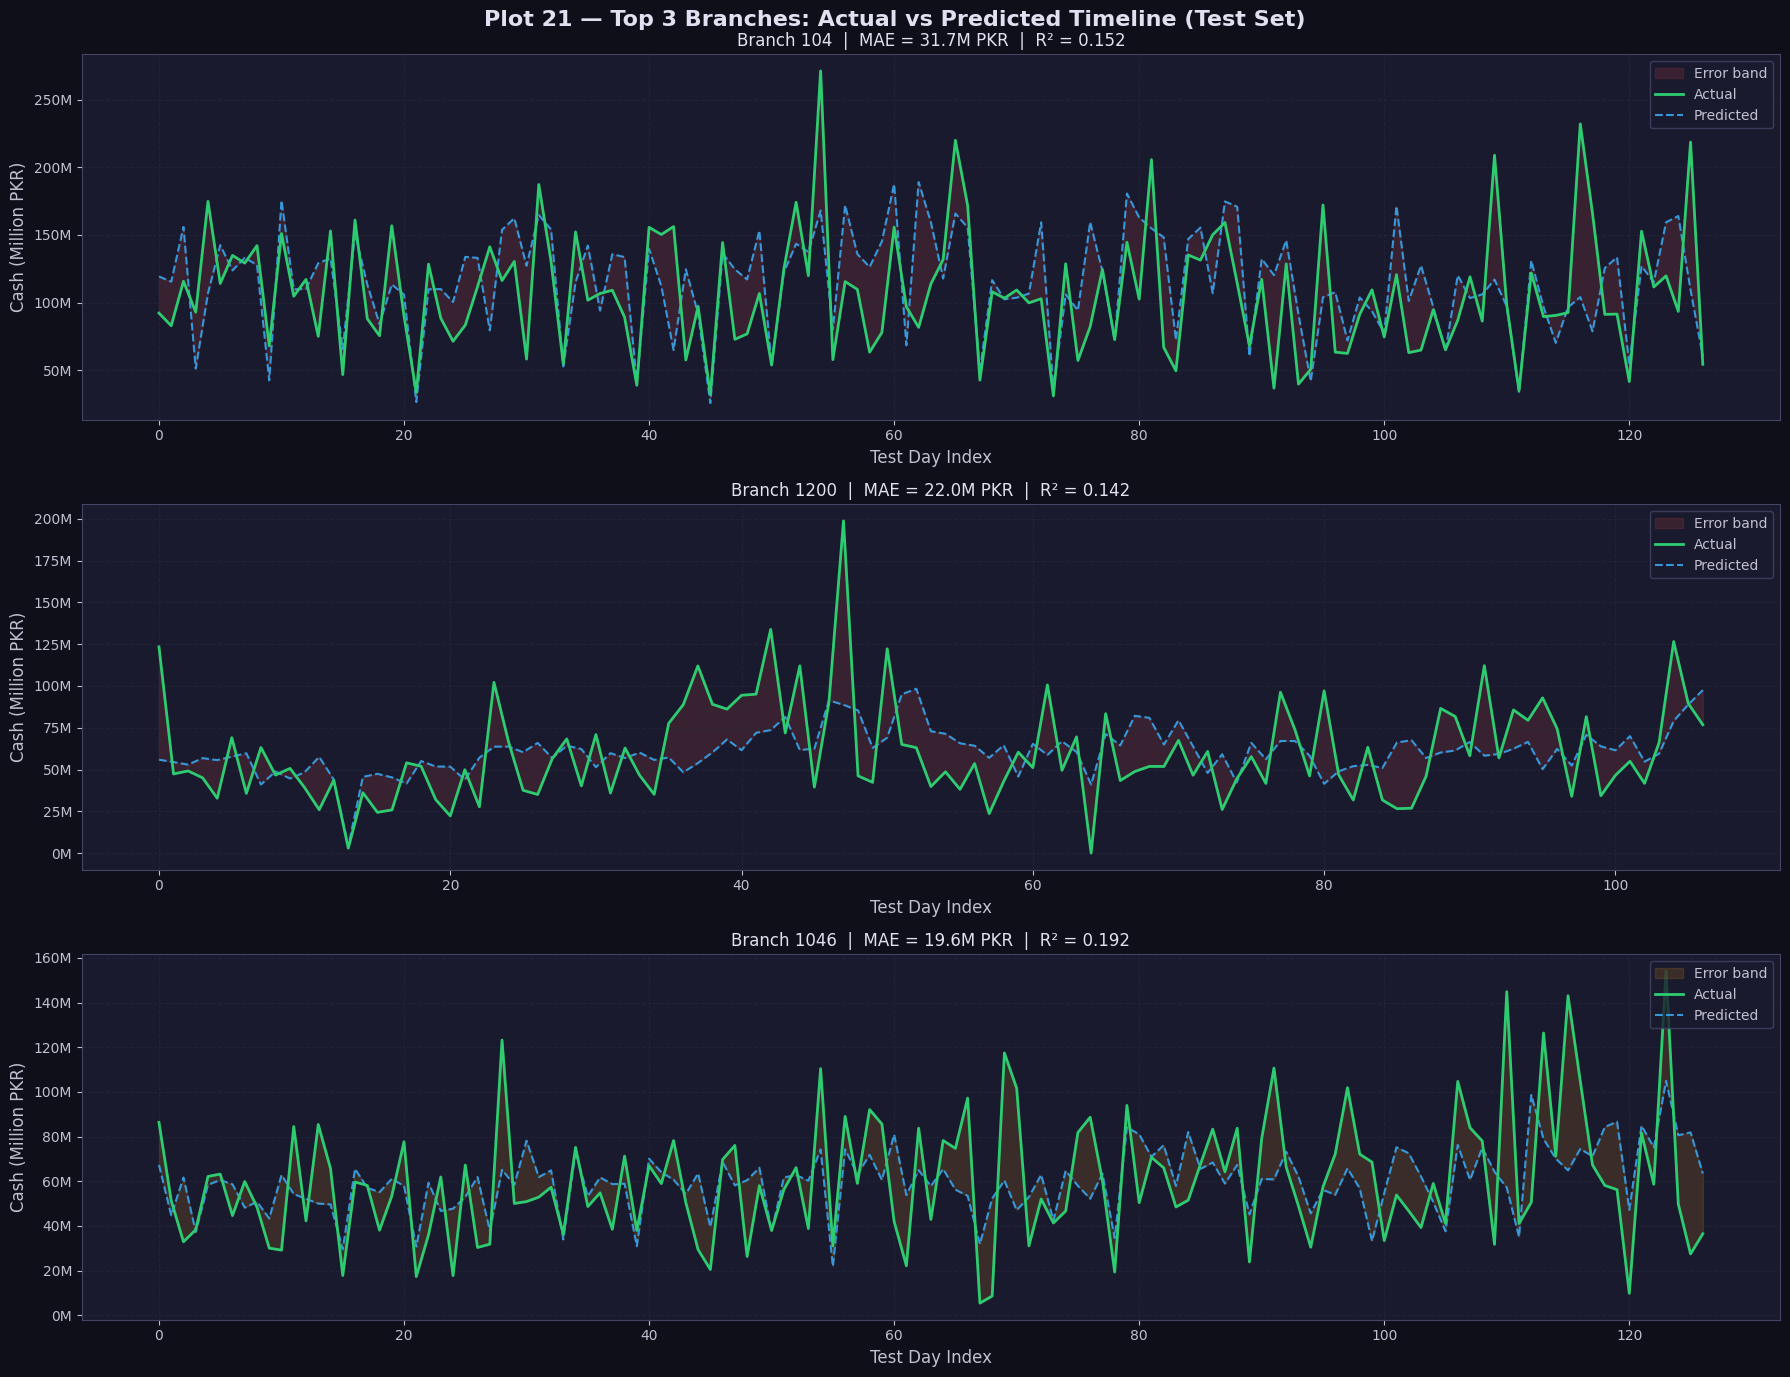

✅ Plot 21 saved: eda_plots/21_top_branches_timeline.png


In [11]:
# ─── Plot 21: Top Branches Timeline ──────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=False)
fig.suptitle('Plot 21 — Top 3 Branches: Actual vs Predicted Timeline (Test Set)',
             fontsize=16, fontweight='bold', color='#e0e0f0')

for idx, branch in enumerate(top3_branches):
    ax = axes[idx]
    
    # Filter test_eval2 for this branch
    br_data = test_eval2[test_eval2['tran_br_code'] == branch].copy().reset_index(drop=True)
    
    x = np.arange(len(br_data))
    actual_m = br_data['y_actual'] / 1e6
    pred_m   = br_data['y_predicted'] / 1e6
    err_m    = (br_data['y_actual'] - br_data['y_predicted']).abs() / 1e6
    
    ax.fill_between(x, actual_m, pred_m, alpha=0.15,
                    color='#e74c3c' if (pred_m - actual_m).mean() > 0 else '#f39c12',
                    label='Error band')
    ax.plot(x, actual_m,  color='#2ecc71', linewidth=2,   label='Actual',    zorder=3)
    ax.plot(x, pred_m,    color='#3498db', linewidth=1.5, label='Predicted',
            linestyle='--', zorder=2)
    
    mae_br  = err_m.mean()
    r2_br   = branch_df[branch_df['Branch'] == branch]['R2'].values[0]
    ax.set_title(f'Branch {branch}  |  MAE = {mae_br:.1f}M PKR  |  R² = {r2_br:.3f}',
                 color='#e0e0f0', fontsize=12)
    ax.set_ylabel('Cash (Million PKR)', color='#c0c0d0')
    ax.set_xlabel('Test Day Index', color='#c0c0d0')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
    ax.legend(facecolor='#1a1a2e', edgecolor='#444466', labelcolor='#c0c0d0',
              loc='upper right')
    ax.grid(True)

plt.tight_layout()
plt.savefig('eda_plots/21_top_branches_timeline.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('✅ Plot 21 saved: eda_plots/21_top_branches_timeline.png')

---
## Step 8: Business Recommendations

In [12]:
# ─── Business Recommendations Table ──────────────────────────────────────────
print('=' * 70)
print('📋  BUSINESS RECOMMENDATIONS — BRANCH-WISE CASH STRATEGY')
print('=' * 70)

recommendations = []
for _, row in branch_df.iterrows():
    mape = row['MAPE_%']
    r2   = row['R2']
    mae  = row['MAE_M']
    avg  = row['Avg_Actual_M']
    
    # Safety buffer based on MAPE
    if mape < 30:
        buffer_pct  = 5
        trust_level = '🟢 HIGH'
        action      = 'Use model directly for replenishment'
    elif mape < 60:
        buffer_pct  = 12
        trust_level = '🟡 MEDIUM'
        action      = 'Add safety buffer, monitor weekly'
    elif mape < 100:
        buffer_pct  = 20
        trust_level = '🟠 MODERATE'
        action      = 'Use with caution, manual override advised'
    else:
        buffer_pct  = 30
        trust_level = '🔴 LOW'
        action      = 'Manual review required — model unreliable for this branch'
    
    safe_amount = avg * (1 + buffer_pct / 100)
    recommendations.append({
        'Branch':         int(row['Branch']),
        'Avg_Demand_M':   avg,
        'MAE_M':          mae,
        'MAPE_%':         mape,
        'R2':             r2,
        'Trust_Level':    trust_level,
        'Buffer_%':       buffer_pct,
        'Recommended_M':  round(safe_amount, 2),
        'Action':         action
    })

rec_df = pd.DataFrame(recommendations).sort_values('Avg_Demand_M', ascending=False)
print(rec_df[['Branch','Avg_Demand_M','MAE_M','MAPE_%','Trust_Level','Buffer_%','Recommended_M']].to_string(index=False))
print()
for _, r in rec_df.iterrows():
    print(f'  Branch {int(r["Branch"]):>5} → {r["Action"]}')

print('=' * 70)

📋  BUSINESS RECOMMENDATIONS — BRANCH-WISE CASH STRATEGY
 Branch  Avg_Demand_M  MAE_M  MAPE_% Trust_Level  Buffer_%  Recommended_M
    104        107.32  31.70    32.8    🟡 MEDIUM        12         120.20
   1200         60.31  22.00    41.2    🟡 MEDIUM        12          67.55
   1046         60.20  19.65    46.9    🟡 MEDIUM        12          67.42
   1297         56.42  11.20    21.2      🟢 HIGH         5          59.24
    234         49.38  13.41    42.2    🟡 MEDIUM        12          55.31
   1376         47.05  14.80    66.5  🟠 MODERATE        20          56.46
    202         44.06  10.31    26.2      🟢 HIGH         5          46.26
   1092         40.79  13.85    43.5    🟡 MEDIUM        12          45.68
    372         34.61  11.84    38.0    🟡 MEDIUM        12          38.76
    659         33.24  10.55    50.0    🟡 MEDIUM        12          37.23
    511         30.83   7.26    25.9      🟢 HIGH         5          32.37
    394         29.91   9.35    41.0    🟡 MEDIUM        

---
## Step 9: Final Report Export

In [13]:
# ─── Save Final Evaluation CSV ────────────────────────────────────────────────
rec_df.to_csv('models/final_evaluation_report.csv', index=False)
print('✅ Saved: models/final_evaluation_report.csv')

branch_df.to_csv('models/branch_metrics.csv', index=False)
print('✅ Saved: models/branch_metrics.csv')

print()
print('📦 Phase 6 Summary:')
print(f'   Overall MAE  : {test_metrics["MAE_M"]} M PKR')
print(f'   Overall RMSE : {test_metrics["RMSE_M"]} M PKR')
print(f'   Overall MAPE : {test_metrics["MAPE_%"]} %')
print(f'   Overall R²   : {test_metrics["R2"]}')
print(f'   Plots saved  : 18, 19, 20, 21 (eda_plots/)')
print(f'   Reports saved: models/final_evaluation_report.csv')
print(f'   Status       : ✅ COMPLETE')

✅ Saved: models/final_evaluation_report.csv
✅ Saved: models/branch_metrics.csv

📦 Phase 6 Summary:
   Overall MAE  : 14.249 M PKR
   Overall RMSE : 20.288 M PKR
   Overall MAPE : 62.13 %
   Overall R²   : 0.5607
   Plots saved  : 18, 19, 20, 21 (eda_plots/)
   Reports saved: models/final_evaluation_report.csv
   Status       : ✅ COMPLETE


In [14]:
# ─── Generate Markdown Report ─────────────────────────────────────────────────
import datetime

md_lines = []
md_lines.append('# 📋 Phase 6 — Evaluation & Final Report\n')
md_lines.append(f'*Generated: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}*\n')
md_lines.append('---\n')

# Overall metrics
md_lines.append('## 📊 Overall Model Performance (Test Set)\n')
md_lines.append('| Metric | Train | Test |\n|---|---|---|\n')
for k in ['MAE_M','RMSE_M','MedAE_M','MAPE_%','R2']:
    md_lines.append(f'| {k} | {train_metrics[k]} | {test_metrics[k]} |\n')

md_lines.append('\n---\n')

# Per-branch
md_lines.append('## 🏦 Per-Branch Evaluation\n')
md_lines.append('| Branch | N Days | Avg Actual M | MAE M | MAPE % | R² |\n')
md_lines.append('|---|---|---|---|---|---|\n')
for _, r in branch_df.iterrows():
    md_lines.append(f'| {int(r["Branch"])} | {r["N_Days"]} | {r["Avg_Actual_M"]} | {r["MAE_M"]} | {r["MAPE_%"]} | {r["R2"]} |\n')

md_lines.append('\n---\n')

# Business recs
md_lines.append('## 💼 Business Recommendations\n')
md_lines.append('| Branch | Avg Demand M | Trust Level | Buffer % | Recommended M |\n')
md_lines.append('|---|---|---|---|---|\n')
for _, r in rec_df.iterrows():
    md_lines.append(f'| {int(r["Branch"])} | {r["Avg_Demand_M"]} | {r["Trust_Level"]} | {r["Buffer_%"]}% | {r["Recommended_M"]} |\n')

md_lines.append('\n---\n')
md_lines.append('## 📈 Plots Generated\n')
md_lines.append('| Plot | File | Description |\n|---|---|---|\n')
md_lines.append('| 18 | `eda_plots/18_branch_wise_evaluation.png` | Per-branch MAE & R² |\n')
md_lines.append('| 19 | `eda_plots/19_error_distribution.png` | Error distribution & pie |\n')
md_lines.append('| 20 | `eda_plots/20_residuals_plot.png` | Residuals analysis |\n')
md_lines.append('| 21 | `eda_plots/21_top_branches_timeline.png` | Top branches timeline |\n')

md_lines.append('\n---\n')
md_lines.append('## ✅ Phase 6 — Final Status\n')
md_lines.append(f'| Item | Value |\n|---|---|\n')
md_lines.append(f'| Model | XGBoost (best_model.pkl) |\n')
md_lines.append(f'| Test MAE | {test_metrics["MAE_M"]} M PKR |\n')
md_lines.append(f'| Test R² | {test_metrics["R2"]} |\n')
md_lines.append(f'| Plots Saved | 4 (18–21) |\n')
md_lines.append(f'| Status | ✅ COMPLETE |\n')

report_path = 'explanation/Phase_6_Final_Report.md'
os.makedirs('explanation', exist_ok=True)
with open(report_path, 'w', encoding='utf-8') as f:
    f.writelines(md_lines)

print(f'✅ Markdown report saved: {report_path}')
print('\n🎉 Phase 6 COMPLETE!')

✅ Markdown report saved: explanation/Phase_6_Final_Report.md

🎉 Phase 6 COMPLETE!
